## Kaggle Setup Note
Uncomment and run the cell below if you are running this notebook in Kaggle to ensure PyTorch Geometric is installed. 
Since Kaggle GPU kernels typically have around ~16GB of RAM, the `SequentialGraphChunkLoader` used below is strictly required to prevent the kernel from crashing with Out-Of-Memory (OOM) errors.

In [ ]:
# !pip install torch_geometric
# !pip install networkx

# Deep Graph Anomaly Detection with Contrastive Learning

This notebook implements Specific Task 1 using a Contrastive Learning approach (GraphCL-style). We learn graph representations of Quark/Gluon jet events and classify them using Linear Probing.

## Outline
1. Import Libraries and Setup
2. Data Loading and Preprocessing
3. Graph Augmentation Strategies
4. Define Contrastive Learning Architecture (GIN)
5. Implement Contrastive Loss Function (InfoNCE)
6. Train Contrastive Encoder
7. Train Downstream Classifier
8. Evaluate Model Performance

In [46]:
# 1. Import Libraries and Setup
import os
import glob
import random
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Batch, Dataset
from torch_geometric.nn import GINConv, global_add_pool, global_mean_pool
from torch_geometric.loader import DataLoader
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# Setup device and random seed
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
print(f"Using device: {device}")

Using device: cuda


In [47]:
# 2. Data Loading and Preprocessing
# Implementing the memory-safe Sequential Chunk Loader compliant with the HDF5_DATA_HANDLING_GUIDE.md
import os
import glob
import random
import torch
from torch_geometric.data import Batch

class SequentialGraphChunkLoader:
    """
    A compliant DataLoader that works WITH the chunk boundaries, not against them.
    1. Read Bulk: Loads exactly one .pt chunk file into RAM.
    2. Shuffle Locally: Shuffles the graphs within that ~1GB footprint to provide randomness.
    3. Discard: Yields batches until empty, then naturally overwrites to load the next chunk.
    """
    def __init__(self, chunk_files, batch_size=128, shuffle=True):
        self.chunk_files = sorted(chunk_files)
        self.batch_size = batch_size
        self.shuffle = shuffle
        
    def __iter__(self):
        for file in self.chunk_files:
            # Load large contiguous block into RAM
            chunk_data = torch.load(file, weights_only=False)
            
            # Local shuffle maintains randomness without thrashing disk/memory
            if self.shuffle:
                random.shuffle(chunk_data)
                
            # Yield full batches from the local buffer
            for i in range(0, len(chunk_data), self.batch_size):
                batch_graphs = chunk_data[i:i + self.batch_size]
                # Combine PyG Data objects into a unified Batch
                yield Batch.from_data_list(batch_graphs)

# --- KAGGLE NOTE ---
# If you uploaded your 'processed_graphs' from Task 2 as a Kaggle dataset,
# change this path to mirror your Kaggle Input path, e.g., '/kaggle/input/ml4sci-task2-graphs/processed_graphs'
PROCESSED_DIR = 'processed_graphs' 
all_chunk_files = sorted(glob.glob(os.path.join(PROCESSED_DIR, 'chunk_*.pt')))

if len(all_chunk_files) == 0:
    print(f"No chunks found in {PROCESSED_DIR}. Make sure you generate graphs first.")

# Split chunk files for Train and Test sets (e.g. 80/20 chunk split)
train_files_count = max(1, int(0.8 * len(all_chunk_files)))
train_chunk_files = all_chunk_files[:train_files_count]
test_chunk_files = all_chunk_files[train_files_count:]

if len(all_chunk_files) > 0:
    print(f"Using {len(train_chunk_files)} chunks for training.")
    print(f"Using {len(test_chunk_files)} chunks for testing.")

Using 17 chunks for training.
Using 5 chunks for testing.


In [48]:
# 3. Graph Augmentation Strategies
# We implement two simple augmentations to generate positive pairs matching GraphCL methodology:
# 1. Edge Dropping: randomly remove a percentage of edges.
# 2. Node Feature Masking: randomly mask (zero out) feature values of a fraction of nodes.

def drop_edges(edge_index, drop_prob=0.2):
    """ Randomly drops edges from the graph. """
    num_edges = edge_index.size(1)
    if num_edges == 0:
        return edge_index
    
    # Generate random mask
    mask = torch.rand(num_edges) > drop_prob
    return edge_index[:, mask]

def mask_node_features(x, mask_prob=0.2):
    """ Randomly masks node features by setting them to zero. """
    x_aug = x.clone()
    num_nodes = x.size(0)
    
    # Mask per node
    mask = torch.rand(num_nodes) < mask_prob
    if mask.any():
        # Using a fixed value (0) for masked nodes
        x_aug[mask] = 0.0
    return x_aug

def generate_augmented_view(batch_data, drop_edge_prob=0.2, mask_node_prob=0.2):
    """ Takes a PyG Batch/Data object and returns a new augmented Batch/Data object. """
    aug_data = batch_data.clone()
    
    # 1. Drop Edges
    aug_data.edge_index = drop_edges(aug_data.edge_index, drop_prob=drop_edge_prob)
    
    # 2. Mask Node Features
    if hasattr(aug_data, 'x') and aug_data.x is not None:
        aug_data.x = mask_node_features(aug_data.x, mask_prob=mask_node_prob)
        
    return aug_data

In [49]:
# 4. Define Contrastive Learning Architecture
# Graph Isomorphism Network (GIN) is proven effective for graph-level representations.
# The projection head maps the GNN embeddings into the contrastive space (usually an MLP).

class GINEncoder(nn.Module):
    def __init__(self, in_channels=5, hidden_dim=64, out_dim=128, num_layers=3):
        super(GINEncoder, self).__init__()
        self.num_layers = num_layers
        self.convs = nn.ModuleList()
        self.batch_norms = nn.ModuleList()
        
        for i in range(num_layers):
            input_dim = in_channels if i == 0 else hidden_dim
            # GIN uses an MLP to learn the message aggregation
            mlp = nn.Sequential(
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            )
            self.convs.append(GINConv(mlp))
            self.batch_norms.append(nn.BatchNorm1d(hidden_dim))
            
        self.fc = nn.Linear(hidden_dim, out_dim)

    def forward(self, x, edge_index, batch):
        h = x
        for i in range(self.num_layers):
            h = self.convs[i](h, edge_index)
            h = self.batch_norms[i](h)
            h = F.relu(h)
        
        # Pool graph node features into a single graph vector
        h_pool = global_mean_pool(h, batch)
        # Final encoder output (often used directly for downstream classification)
        return self.fc(h_pool)

class GraphCL(nn.Module):
    def __init__(self, encoder, hidden_dim=128, proj_dim=64):
        super(GraphCL, self).__init__()
        self.encoder = encoder
        # Projection head maps to contrastive latent space
        self.proj_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, proj_dim)
        )
        
    def forward(self, data):
        # Extract graph representation
        emb = self.encoder(data.x, data.edge_index, data.batch)
        # Map to contrastive space
        z = self.proj_head(emb)
        return emb, z

In [50]:
# 5. Implement Contrastive Loss Function
# We use the InfoNCE (Normalized Temperature-scaled Cross Entropy) Loss.
# It repels different graphs in the batch while attracting the 2 augmented views of the same graph.

def info_nce_loss(z1, z2, temperature=0.1):
    """
    Computes InfoNCE loss given two augmented views of a batch of graphs.
    z1, z2: Output embeddings from the projection head, shape: [batch_size, proj_dim]
    """
    batch_size = z1.size(0)
    # L2 normalize embeddings
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    
    # Calculate cosine similarity matrices (all vs all)
    # Each row corresponds to a single graph
    sim_11 = torch.matmul(z1, z1.T) / temperature
    sim_22 = torch.matmul(z2, z2.T) / temperature
    sim_12 = torch.matmul(z1, z2.T) / temperature
    
    # Create labels: the positive pairs are on the diagonals of sim_12
    labels = torch.arange(batch_size, device=z1.device)
    
    # Mask out self-similarity from sim_11 and sim_22 by replacing diagonal with -inf
    diag_mask = torch.eye(batch_size, dtype=torch.bool, device=z1.device)
    sim_11.masked_fill_(diag_mask, -9e15)
    sim_22.masked_fill_(diag_mask, -9e15)
    
    # Compute loss for view 1 matching to view 2
    logits_1 = torch.cat([sim_12, sim_11], dim=1)
    loss_1 = F.cross_entropy(logits_1, labels)

    # Compute loss for view 2 matching to view 1
    logits_2 = torch.cat([sim_12.T, sim_22], dim=1)
    loss_2 = F.cross_entropy(logits_2, labels)
    
    return (loss_1 + loss_2) / 2.0

Starting Contrastive Pre-training...


Epoch 1/5 (Pre-train): 0it [00:00, ?it/s]

Epoch 1 | Average Contrastive Loss: 0.1687


Epoch 2/5 (Pre-train): 0it [00:00, ?it/s]

Epoch 2 | Average Contrastive Loss: 0.0544


...

Epoch 3 | Average Contrastive Loss: 0.0459


Epoch 4/5 (Pre-train): 0it [00:00, ?it/s]

Epoch 4 | Average Contrastive Loss: 0.0391


Epoch 5/5 (Pre-train): 0it [00:00, ?it/s]

Epoch 5 | Average Contrastive Loss: 0.0400


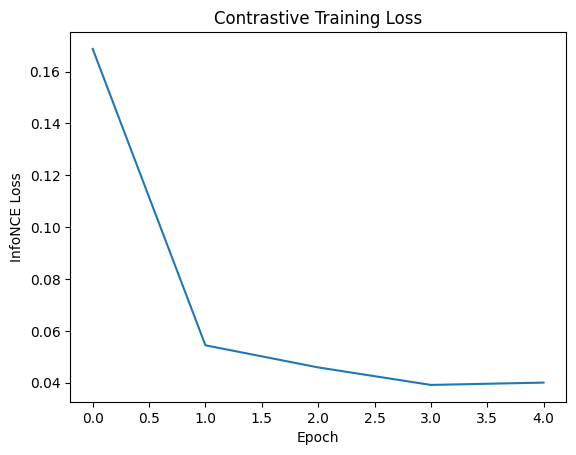

In [51]:
# 6. Train Contrastive Encoder
batch_size = 128
epochs_pretrain = 5  # Reduce this if doing a quick test, e.g., 1 or 2.

train_loader = SequentialGraphChunkLoader(train_chunk_files, batch_size=batch_size, shuffle=True)
test_loader = SequentialGraphChunkLoader(test_chunk_files, batch_size=batch_size, shuffle=False)

encoder = GINEncoder(in_channels=5, hidden_dim=64, out_dim=128, num_layers=3)
model = GraphCL(encoder, hidden_dim=128, proj_dim=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

print("Starting Contrastive Pre-training...")
loss_history = []

for epoch in range(1, epochs_pretrain + 1):
    model.train()
    epoch_loss = 0.0
    epoch_graphs = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs_pretrain} (Pre-train)")
    
    for batch_idx, data in enumerate(pbar):
        optimizer.zero_grad()
        
        # 1. Generate two augmented views (they might contain CPU tensors, so we do it before to(device))
        view1_data = Batch.from_data_list([generate_augmented_view(d) for d in data.to_data_list()]).to(device)
        view2_data = Batch.from_data_list([generate_augmented_view(d) for d in data.to_data_list()]).to(device)
        
        # 2. Extract projection embeddings
        _, z1 = model(view1_data)
        _, z2 = model(view2_data)
        
        # 3. Compute InfoNCE Loss
        loss = info_nce_loss(z1, z2, temperature=0.1)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * data.num_graphs
        epoch_graphs += data.num_graphs
        pbar.set_postfix({'loss': loss.item()})
        
    avg_loss = epoch_loss / epoch_graphs if epoch_graphs > 0 else 0
    loss_history.append(avg_loss)
    print(f"Epoch {epoch} | Average Contrastive Loss: {avg_loss:.4f}")

plt.plot(loss_history)
plt.title("Contrastive Training Loss")
plt.xlabel("Epoch")
plt.ylabel("InfoNCE Loss")
plt.show()

In [52]:
# 7. Train Downstream Classifier (Linear Probing)
# Since we pre-trained the encoder without labels using purely graph structures, we now evaluation its
# representation quality by freezing it and training a simple Logistic Regression model on the Quarks (0) vs Gluons (1) classes.

@torch.no_grad()
def extract_embeddings(loader, model, device):
    """
    Passes all data through the FROZEN encoder and collects graph-level embeddings + labels.
    """
    model.eval()
    embeddings = []
    labels = []
    
    pbar = tqdm(loader, desc="Extracting Embeddings")
    for data in pbar:
        data = data.to(device)
        # We only use the encoder structure here, bypassing the projection head used in pre-training.
        emb = model.encoder(data.x, data.edge_index, data.batch)
        
        embeddings.append(emb.cpu().numpy())
        labels.append(data.y.cpu().numpy())
        
        # Optional quick experimentation cap
        # if len(embeddings) > 100: break
        
    return np.concatenate(embeddings), np.concatenate(labels)

print("Extracting train embeddings...")
X_train_emb, y_train = extract_embeddings(train_loader, model, device)

print("Extracting test embeddings...")
X_test_emb, y_test = extract_embeddings(test_loader, model, device)

# StandardScaler improves linear model convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_emb)
X_test_scaled = scaler.transform(X_test_emb)

# Quick sanity check
print(f"Train embeddings shape: {X_train_scaled.shape}, Test embeddings shape: {X_test_scaled.shape}")

# Train the Logistic Regression classifier
classifier = LogisticRegression(max_iter=1000)
print("Training Linear Classifier on Top of Frozen Representations...")
classifier.fit(X_train_scaled, y_train)

Extracting train embeddings...


Extracting Embeddings: 0it [00:00, ?it/s]

Extracting test embeddings...


Extracting Embeddings: 0it [00:00, ?it/s]

Train embeddings shape: (107306, 128), Test embeddings shape: (32000, 128)
Training Linear Classifier on Top of Frozen Representations...


LogisticRegression(max_iter=1000)

=== Linear Probing Results ===
Accuracy: 0.6107
ROC-AUC:  0.6480

Classification Report:
              precision    recall  f1-score   support

   Quark (0)       0.61      0.62      0.61     15997
   Gluon (1)       0.61      0.60      0.61     16003

    accuracy                           0.61     32000
   macro avg       0.61      0.61      0.61     32000
weighted avg       0.61      0.61      0.61     32000



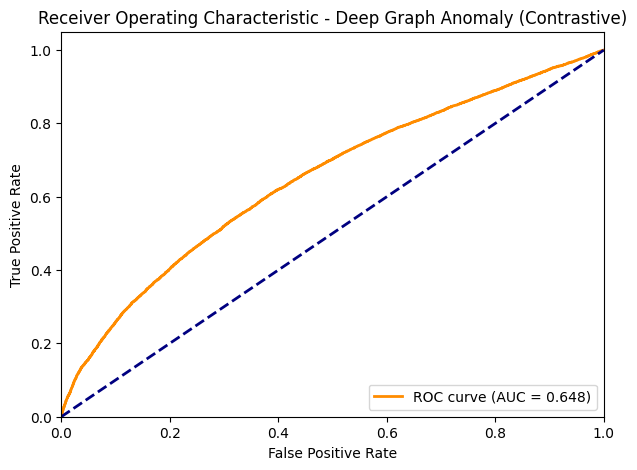

In [53]:
# 8. Evaluate Model Performance
from sklearn.metrics import classification_report, confusion_matrix, roc_curve

# Predict classes and probabilities
y_pred = classifier.predict(X_test_scaled)
y_pred_proba = classifier.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred_proba)

print(f"=== Linear Probing Results ===")
print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC:  {roc:.4f}")
print("==============================\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Quark (0)', 'Gluon (1)']))

# Plot ROC-AUC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Deep Graph Anomaly (Contrastive)')
plt.legend(loc="lower right")
plt.show()